In [5]:
import geopandas as gpd
import matplotlib.pyplot as plt

In [ ]:
# use calving fronts as antarctica background
bucket = 's3://EarthCODE/'
endpoint_url = "https://s3.waw4-1.cloudferro.com"
region_name = "eu-west-2"
file = 'OSCAssets/polar_cube_datasets/calving_fronts/Antarctic_coastlines.parquet'

gdf = gpd.read_parquet(
    f"{bucket}{file}",
    storage_options={ "anon": True, 
                    "client_kwargs": {
                        "endpoint_url": endpoint_url,
                        "region_name": region_name
                    }
    }
)

gdf['area'] = gdf.area
largest_polygon = gdf.sort_values('area', ascending=False).iloc[[0]]

In [6]:
# Read the subglacial lakes boundaries
bucket = 's3://EarthCODE/'
endpoint_url = "https://s3.waw4-1.cloudferro.com"
region_name = "eu-west-2"
file = 'OSCAssets/polar_cube_datasets/subglacial_lakes/subglacial_lakes_boundries.parquet'


gdf = gpd.read_parquet(
    f"{bucket}{file}",
    storage_options={ "anon": True, 
                    "client_kwargs": {
                        "endpoint_url": endpoint_url,
                        "region_name": region_name
                    }
    }
)

gdf['area'] = gdf.area
gdf

/tmp/ipykernel_22119/3385685713.py:18: UserWarning: Geometry is in a geographic CRS. Results from 'area' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  gdf['area'] = gdf.area


,record_id,name,new_sgl_glake,start_date,end_date,contour_m_yr,geometry,area
0,Byrd_10_201107-201609_0.6,Byrd_10,False,2011-07-01,2016-09-01,0.6,"POLYGON ((-145.693 -79.91919, -145.66116 -79.9...",0.058747
1,Jutulstraumen_74_201509-202007_0.5,Jutulstraumen_74,False,2015-09-01,2020-07-01,0.5,"POLYGON ((149.03818 -70.90299, 149.03017 -70.8...",0.036503
2,Borchgrevink_198_201412-202007_0.3,Borchgrevink_198,False,2014-12-01,2020-07-01,0.3,"POLYGON ((155.3791 -75.47119, 155.36316 -75.46...",0.058957
3,Totten_36_201202-202007_0.1,Totten_36,False,2012-02-01,2020-07-01,0.1,"POLYGON ((-148.9065 -84.70493, -148.91801 -84....",0.115222
4,Academy_45_201512-202007_0.4,Academy_45,False,2015-12-01,2020-07-01,0.4,"POLYGON ((-83.90481 -78.1871, -83.90071 -78.19...",0.052464
...,...,...,...,...,...,...,...,...
151,Mercer2_201402_201807_0.8,Mercer2,True,2014-02-01,2018-07-01,0.8,"POLYGON ((148.152 -68.57873, 148.14392 -68.575...",0.003852
152,Mac3_201209_201904_0.3,Mac3,True,2012-09-01,2019-04-01,0.3,"POLYGON ((112.56294 -67.59883, 112.5586 -67.59...",0.007689
153,THW170_201605_201902_0.8,THW170,True,2016-05-01,2019-02-01,0.8,"POLYGON ((-120.11364 -75.35571, -120.10997 -75...",0.008920
154,Institute_E1b_201402_201804_0.4,Institute_E1b,True,2014-02-01,2018-04-01,0.4,"POLYGON ((110.71122 -66.84517, 110.70411 -66.8...",0.001522


Text(0.5, 1.0, 'New vs old subglacial lakes')

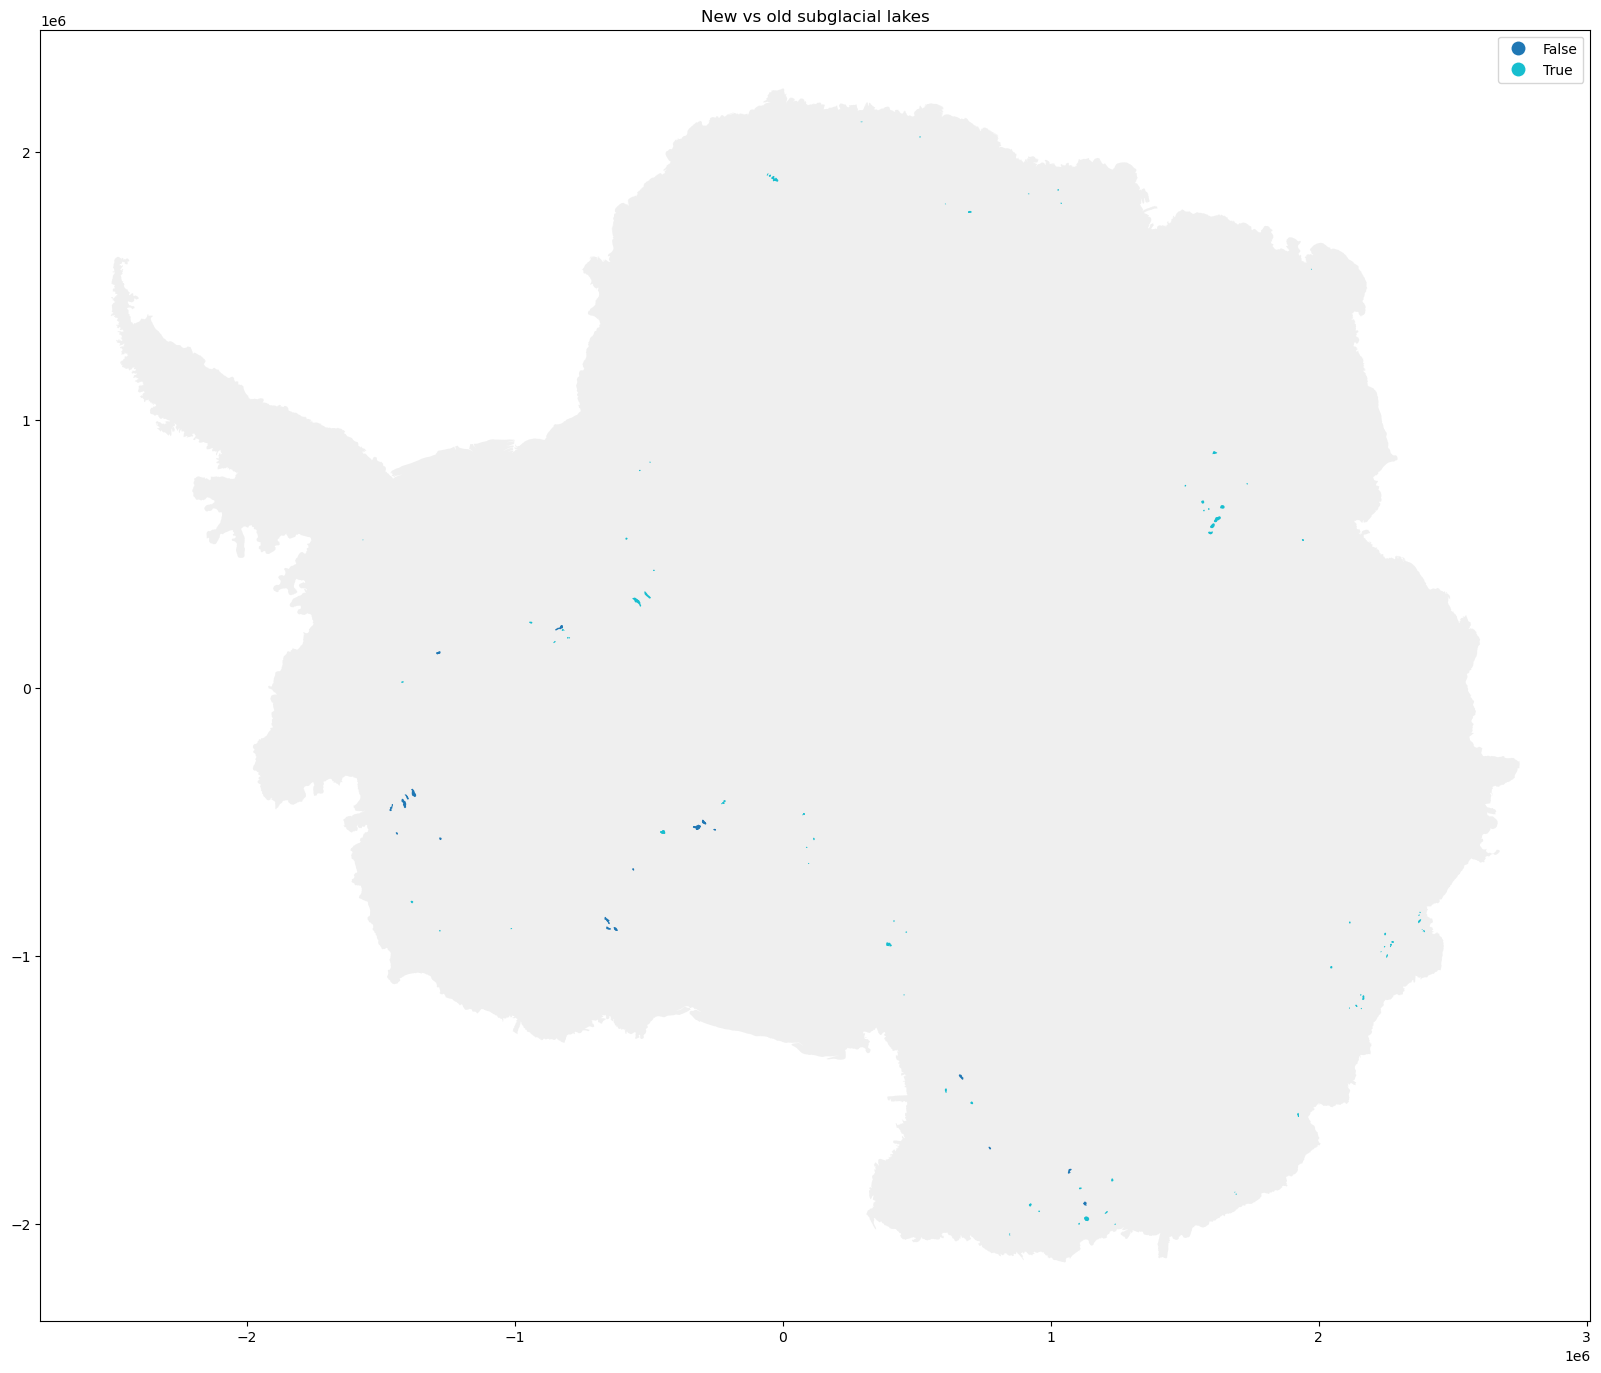

In [8]:
fig, ax = plt.subplots(figsize=(20,20))
largest_polygon.plot(ax=ax, alpha=.12, color='grey')
gdf.to_crs(epsg=3031).plot(column='new_sgl_glake', legend=True, ax=ax)
ax.set_title('New vs old subglacial lakes')